In [1]:
import os
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import shutil #用于拷贝
import xml.etree.ElementTree as ET
import pydicom

d:\anaconda\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [ ]:
# 提取t2文件夹内dcm绝对路径
import os

def get_t2_paths(root_dir):
    t2_paths = []
    for patient_folder in os.listdir(root_dir):
        patient_folder_path = os.path.join(root_dir, patient_folder)
        # 确保是文件夹
        if os.path.isdir(patient_folder_path):
            sag_folder_path = os.path.join(patient_folder_path, 'sag', 't2')
            if os.path.exists(sag_folder_path) and os.path.isdir(sag_folder_path):
                # 遍历 t2 文件夹中的所有 dcm 文件
                for filename in os.listdir(sag_folder_path):
                    if filename.endswith('.dcm'): 
                        t2_paths.append(os.path.join(sag_folder_path, filename))
    return t2_paths

train_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/train-sag"
valid_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/valid-sag"
test_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/test-sag"

train_t2_dcm = get_t2_paths(train_root_dir)
valid_t2_dcm = get_t2_paths(valid_root_dir)
test_t2_dcm = get_t2_paths(test_root_dir)

print("Train T2 dcm paths:")
print(train_t2_dcm)
print("\nValid T2 dcm paths:")
print(valid_t2_dcm)
print("\nTest T2 dcm paths:")
print(test_t2_dcm)


Train T2 JPG paths:
['D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_1.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_10.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_11.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_12.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_13.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_14.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_2.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_3.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train

In [ ]:
# json files
import os
import json
import torch
import shutil
from PIL import Image

def create_empty_json_for_dcm(dcm_path, new_root_dir, root_dir):
    original_folder = os.path.dirname(dcm_path)
    
    relative_path = os.path.relpath(original_folder, start=root_dir) 
    new_json_folder = os.path.join(new_root_dir, relative_path)
    
    if not os.path.exists(new_json_folder):
        os.makedirs(new_json_folder)
    
    with Image.open(dcm_path) as img:
        width, height = img.size
    
    json_path = os.path.join(new_json_folder, os.path.basename(dcm_path).replace('.dcm', '.json'))
    
    empty_json = {
        "version": "5.2.0.post4",
        "flags": {},
        "shapes": [
            {
                "label": "0",  
                "points": [],  
                "shape_type": "rectangle",  
                "flags": {}
            }
        ],
        "imagePath": os.path.basename(dcm_path),
        "imageHeight": height,  
        "imageWidth": width    
    }
    
    with open(json_path, 'w') as f:
        json.dump(empty_json, f, indent=4)
    
    print(f"Created empty JSON file: {json_path}")
    return json_path

def copy_existing_json_to_new_folder(dcm_path, new_root_dir, root_dir):
    json_path = dcm_path.replace('.dcm', '.json')
    
    if os.path.exists(json_path):
        original_folder = os.path.dirname(dcm_path)
        
        relative_path = os.path.relpath(original_folder, start=root_dir)
        new_json_folder = os.path.join(new_root_dir, relative_path)
        
        if not os.path.exists(new_json_folder):
            os.makedirs(new_json_folder)
        
        new_json_path = os.path.join(new_json_folder, os.path.basename(json_path))
        
        shutil.copy(json_path, new_json_path)
        print(f"Copied existing JSON file: {json_path} to {new_json_path}")
        return new_json_path
    return None

def get_json_paths_and_create_missing(dcm_paths, root_dir, new_root_dir):
    t2_json_paths = []
    
    for dcm_path in dcm_paths:
        json_path = dcm_path.replace('.dcm', '.json')
        
        if os.path.exists(json_path):
            copied_json_path = copy_existing_json_to_new_folder(dcm_path, new_root_dir, root_dir)
            if copied_json_path:
                t2_json_paths.append(copied_json_path)
        else:
            created_json_path = create_empty_json_for_dcm(dcm_path, new_root_dir, root_dir)
            t2_json_paths.append(created_json_path)
    
    return t2_json_paths

generated_json_root = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/generated_jsons_v2"
train_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/train-sag"
valid_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/valid-sag"
test_root_dir = "D:/MED/SpM/SpMdcm-20240920-sagcopy-mini/test-sag"

train_t2_json = get_json_paths_and_create_missing(train_t2_dcm, train_root_dir, os.path.join(generated_json_root, "train-sag"))
valid_t2_json = get_json_paths_and_create_missing(valid_t2_dcm, valid_root_dir, os.path.join(generated_json_root, "valid-sag"))
test_t2_json = get_json_paths_and_create_missing(test_t2_dcm, test_root_dir, os.path.join(generated_json_root, "test-sag"))

print("\nGenerated JSON paths for train-sag:")
for json_path in train_t2_json:
    print(json_path)

print("\nGenerated JSON paths for valid-sag:")
for json_path in valid_t2_json:
    print(json_path)

print("\nGenerated JSON paths for test-sag:")
for json_path in test_t2_json:
    print(json_path)


Created empty JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_1.json
Copied existing JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_10.json to D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_10.json
Created empty JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_11.json
Created empty JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_12.json
Created empty JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-CHENG QIAN QIAN\sag\t2\t2_tse_sag_384_13.json
Created empty JSON file: D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\train-sag\20170324000769-C

In [ ]:
# label check
import json
import os

valid_labels = {'0', '1','4','5','6'}

dst_directory = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\generated_jsons_v2"

abnormal_json_files = []

for root, _, files in os.walk(dst_directory):
    for file in files:
        if file.endswith('.json'):
            json_path = os.path.join(root, file)
            with open(json_path, 'r') as json_file:
                try:
                    data = json.load(json_file)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON file {json_path}: {e}")
                    continue

                shapes = data.get('shapes', [])
                
                if not isinstance(shapes, list):
                    continue  

                for shape in shapes:
                    if isinstance(shape, dict):
                        label = shape.get('label', None)
                        if label is not None and label not in valid_labels:
                            abnormal_json_files.append(json_path)
                            break  

if abnormal_json_files:
    print("包含异常值的JSON文件:")
    for abnormal_file in abnormal_json_files:
        print(abnormal_file)
else:
    print("所有JSON文件的label均在合法范围内")

所有JSON文件的label均在合法范围内


In [ ]:
# label modification
import os
import json

def modify_labels_in_json(json_folder):
    for root, dirs, files in os.walk(json_folder):
        for file in files:
            if file.endswith(".json"):
                json_path = os.path.join(root, file)
                
                with open(json_path, 'r') as f:
                    data = json.load(f)
                
                modified = False
                for shape in data.get("shapes", []):
                    if shape.get("label") in ["4", "5", "6"]:
                        shape["label"] = "1"
                        modified = True
                
                if modified:
                    with open(json_path, 'w') as f:
                        json.dump(data, f, indent=4)
                    print(f"Modified {json_path}")
                else:
                    print(f"No modification needed for {json_path}")

json_folder = "D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2"
modify_labels_in_json(json_folder)

No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_1.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_10.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_11.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_12.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_13.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_v2\test-sag\20170506000176-ZHENG XIN LAI\sag\t2\II_t2_fse_sag_14.json
No modification needed for D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/generated_jsons_

In [ ]:
# categorize files by label
import json

def categorize_files_by_label(json_paths, image_paths):
    label_0_dcm, label_0_json = [], []
    label_1_dcm, label_1_json = [], []
    label_1s_dcm, label_1s_json = [], []
    
    for json_path, image_path in zip(json_paths, image_paths):
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
                labels = [shape['label'] for shape in data['shapes'] if shape['label'] == "1"]
                if len(labels) == 0:
                    label_0_dcm.append(image_path)
                    label_0_json.append(json_path)
                elif len(labels) == 1:
                    label_1_dcm.append(image_path)
                    label_1_json.append(json_path)
                else:
                    label_1s_dcm.append(image_path)
                    label_1s_json.append(json_path)
        except Exception as e:
            print(f"Error processing file {json_path}: {e}")
    
    return {
        "label_0": {"dcm": label_0_dcm, "json": label_0_json},
        "label_1_single": {"dcm": label_1_dcm, "json": label_1_json},
        "label_1_multiple": {"dcm": label_1s_dcm, "json": label_1s_json}
    }

train_results = categorize_files_by_label(train_t2_json, train_t2_dcm)
valid_results = categorize_files_by_label(valid_t2_json, valid_t2_dcm)
test_results = categorize_files_by_label(test_t2_json, test_t2_dcm)

train_t2_dcm_label0 = train_results["label_0"]["dcm"]
train_t2_json_label0 = train_results["label_0"]["json"]
train_t2_dcm_label1 = train_results["label_1_single"]["dcm"]
train_t2_json_label1 = train_results["label_1_single"]["json"]
train_t2_dcm_label1s = train_results["label_1_multiple"]["dcm"]
train_t2_json_label1s = train_results["label_1_multiple"]["json"]

valid_t2_dcm_label0 = valid_results["label_0"]["dcm"]
valid_t2_json_label0 = valid_results["label_0"]["json"]
valid_t2_dcm_label1 = valid_results["label_1_single"]["dcm"]
valid_t2_json_label1 = valid_results["label_1_single"]["json"]
valid_t2_dcm_label1s = valid_results["label_1_multiple"]["dcm"]
valid_t2_json_label1s = valid_results["label_1_multiple"]["json"]

test_t2_dcm_label0 = test_results["label_0"]["dcm"]
test_t2_json_label0 = test_results["label_0"]["json"]
test_t2_dcm_label1 = test_results["label_1_single"]["dcm"]
test_t2_json_label1 = test_results["label_1_single"]["json"]
test_t2_dcm_label1s = test_results["label_1_multiple"]["dcm"]
test_t2_json_label1s = test_results["label_1_multiple"]["json"]

print(len(train_t2_dcm_label0));print(len(train_t2_dcm_label1));print(len(train_t2_dcm_label1s))
print(len(valid_t2_dcm_label0));print(len(valid_t2_dcm_label1));print(len(valid_t2_dcm_label1s))
print(len(test_t2_dcm_label0));print(len(test_t2_dcm_label1));print(len(test_t2_dcm_label1s))

3211
421
16
1762
124
5
1757
126
7


In [ ]:
# dataset save
import json
import os

save_file = os.path.join(r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini", "dataset_sag_v2.json")

os.makedirs(os.path.dirname(save_file), exist_ok=True)

train_t2_dcm_positive = train_t2_dcm_label1 + train_t2_dcm_label1s
train_t2_json_positive = train_t2_json_label1 + train_t2_json_label1s

valid_t2_dcm_positive = valid_t2_dcm_label1 + valid_t2_dcm_label1s
valid_t2_json_positive = valid_t2_json_label1 + valid_t2_json_label1s

test_t2_dcm_positive = test_t2_dcm_label1 + test_t2_dcm_label1s
test_t2_json_positive = test_t2_json_label1 + test_t2_json_label1s

data = {
    'train_t2_dcm': train_t2_dcm, 'valid_t2_dcm': valid_t2_dcm, 'test_t2_dcm': test_t2_dcm,
    'train_t2_json': train_t2_json, 'valid_t2_json': valid_t2_json, 'test_t2_json': test_t2_json,
    'train_t2_dcm_label0': train_t2_dcm_label0,
    'train_t2_dcm_label1': train_t2_dcm_label1,
    'train_t2_dcm_label1s': train_t2_dcm_label1s,
    'train_t2_json_label0': train_t2_json_label0,
    'train_t2_json_label1': train_t2_json_label1,
    'train_t2_json_label1s': train_t2_json_label1s,
    'valid_t2_dcm_label0': valid_t2_dcm_label0,
    'valid_t2_dcm_label1': valid_t2_dcm_label1,
    'valid_t2_dcm_label1s': valid_t2_dcm_label1s,
    'valid_t2_json_label0': valid_t2_json_label0,
    'valid_t2_json_label1': valid_t2_json_label1,
    'valid_t2_json_label1s': valid_t2_json_label1s,
    'test_t2_dcm_label0': test_t2_dcm_label0,
    'test_t2_dcm_label1': test_t2_dcm_label1,
    'test_t2_dcm_label1s': test_t2_dcm_label1s,
    'test_t2_json_label0': test_t2_json_label0,
    'test_t2_json_label1': test_t2_json_label1,
    'test_t2_json_label1s': test_t2_json_label1s,
    
    'train_t2_dcm_positive': train_t2_dcm_positive,
    'train_t2_json_positive': train_t2_json_positive,
    'valid_t2_dcm_positive': valid_t2_dcm_positive,
    'valid_t2_json_positive': valid_t2_json_positive,
    'test_t2_dcm_positive': test_t2_dcm_positive,
    'test_t2_json_positive': test_t2_json_positive,

}

with open(save_file, 'w') as f:
    json.dump(data, f)

print(f"数据集已成功保存到 {save_file}")


数据集已成功保存到 D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\dataset_sag_v2.json


In [ ]:
# dataset load
import json, os

save_file = os.path.join(r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini", "dataset_sag_v2.json")

with open(save_file, 'r') as f:
    data = json.load(f)
    train_t2_dcm, train_t2_json = data['train_t2_dcm'], data['train_t2_json']
    train_t2_dcm_label0, train_t2_json_label0 = data['train_t2_dcm_label0'], data['train_t2_json_label0']
    train_t2_dcm_label1, train_t2_json_label1 = data['train_t2_dcm_label1'], data['train_t2_json_label1']
    train_t2_dcm_label1s, train_t2_json_label1s = data['train_t2_dcm_label1s'], data['train_t2_json_label1s']
    valid_t2_dcm, valid_t2_json = data['valid_t2_dcm'], data['valid_t2_json']
    valid_t2_dcm_label0, valid_t2_json_label0 = data['valid_t2_dcm_label0'], data['valid_t2_json_label0']
    valid_t2_dcm_label1, valid_t2_json_label1 = data['valid_t2_dcm_label1'], data['valid_t2_json_label1']
    valid_t2_dcm_label1s, valid_t2_json_label1s = data['valid_t2_dcm_label1s'], data['valid_t2_json_label1s']
    test_t2_dcm, test_t2_json = data['test_t2_dcm'], data['test_t2_json']
    test_t2_dcm_label0, test_t2_json_label0 = data['test_t2_dcm_label0'], data['test_t2_json_label0']
    test_t2_dcm_label1, test_t2_json_label1 = data['test_t2_dcm_label1'], data['test_t2_json_label1']
    test_t2_dcm_label1s, test_t2_json_label1s = data['test_t2_dcm_label1s'], data['test_t2_json_label1s']
    train_t2_dcm_positive, train_t2_json_positive = data['train_t2_dcm_positive'], data['train_t2_json_positive']
    valid_t2_dcm_positive, valid_t2_json_positive = data['valid_t2_dcm_positive'], data['valid_t2_json_positive']
    test_t2_dcm_positive, test_t2_json_positive = data['test_t2_dcm_positive'], data['test_t2_json_positive']
    # train_t2_dcm_positive_aug, train_t2_json_positive_aug = data['train_t2_dcm_positive_aug'], data['train_t2_json_positive_aug']
    # train_t2_dcm_label1_aug, train_t2_json_label1_aug = data['train_t2_dcm_label1_aug'], data['train_t2_json_label1_aug']
# 打印提取结果（可选）
print("Train t2 dcm paths:", train_t2_dcm[:5]); print("Valid t2 dcm paths:", valid_t2_dcm[:5]); print("Test t2 dcm paths:", test_t2_dcm[:5])

    

Train t2 jpg paths: ['D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_1.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_10.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_11.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_12.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_13.jpg']
Valid t2 jpg paths: ['D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_1.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_10.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_11.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/vali

In [ ]:
# data augmentation
import albumentations as A
import cv2
import json
import os
import numpy as np

# 定义数据增强管道
transform = A.Compose(
    [
        A.InvertImg(p=0.2),  
        A.RandomBrightnessContrast(
          brightness_limit=0.2, 
          contrast_limit=0.2,   
          brightness_by_max=True,
          p=0.5                 
        ),
        A.GaussNoise(var_limit=800, 
                     mean=0,  
                     p=0.5                 
        ),
        A.GaussianBlur(blur_limit=(5, 7),  
                       sigma_limit=0,      
                       p=0.5               
        ),
        A.ShiftScaleRotate(
            shift_limit=0.15,
            scale_limit=0.25,
            rotate_limit=0,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        )
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc', 
        label_fields=['class_labels']
    )
)

augmented_image_dir = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_dcm_positive_aug"
augmented_json_dir = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_json_positive_aug"
os.makedirs(augmented_image_dir, exist_ok=True)
os.makedirs(augmented_json_dir, exist_ok=True)

def get_base_filename(img_path):
    directory_path, file_name = os.path.split(img_path)
    base_filename_parts = [p for p in directory_path.split("\\") if p]
    new_base_filename = f"{base_filename_parts[-3]}_{file_name.replace('.json', '').replace('.dcm', '')}"
    return new_base_filename

def apply_augmentation(img_path, json_path):
    new_base_filename = get_base_filename(img_path)
    
    image = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        print(f"Error: Failed to read image {img_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    bboxes = []
    labels = []
    for shape in data.get('shapes', []):
        if shape['shape_type'] == 'rectangle':
            [[xmin, ymin], [xmax, ymax]] = shape['points']
            bboxes.append([xmin, ymin, xmax, ymax]) 
            labels.append(shape['label'])
    
    orig_img_path = os.path.join(augmented_image_dir, f"{new_base_filename}.dcm")
    orig_json_path = os.path.join(augmented_json_dir, f"{new_base_filename}.json")
    cv2.imwrite(orig_img_path, cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))
    data['imagePath'] = f"{new_base_filename}.dcm"
    with open(orig_json_path, 'w') as f:
        json.dump(data, f)

    for i in range(3):
        try:
            transformed = transform(image=image_rgb, bboxes=bboxes, class_labels=labels)
            
            aug_img_filename = f"{new_base_filename}_aug{i}.dcm"
            aug_json_filename = f"{new_base_filename}_aug{i}.json"
            aug_img_path = os.path.join(augmented_image_dir, aug_img_filename)
            aug_json_path = os.path.join(augmented_json_dir, aug_json_filename)
            
            cv2.imwrite(aug_img_path, cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR))
            
            aug_data = data.copy()
            aug_data['imagePath'] = aug_img_filename
            aug_data['shapes'] = []
            
            for bbox, label in zip(transformed['bboxes'], transformed['class_labels']):
                xmin, ymin, xmax, ymax = bbox
                xmin = max(0, min(xmin, width-1))
                ymin = max(0, min(ymin, height-1))
                xmax = max(0, min(xmax, width-1))
                ymax = max(0, min(ymax, height-1))
                
                if xmax > xmin and ymax > ymin:
                    aug_data['shapes'].append({
                        "label": label,
                        "points": [[xmin, ymin], [xmax, ymax]],  
                        "group_id": None,
                        "description": "",
                        "shape_type": "rectangle",
                        "flags": {}
                    })
            
            with open(aug_json_path, 'w') as f:
                json.dump(aug_data, f)
                
            print(f"已保存增强样本: {aug_img_path}")
            
        except Exception as e:
            print(f"增强失败 {img_path} (aug{i}): {str(e)}")

for img_path, json_path in zip(train_t2_dcm_positive, train_t2_json_positive):
    apply_augmentation(img_path, json_path)

print("数据增强完成！")

已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug0.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug1.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug2.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_9_aug0.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_9_aug1.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_9_aug2.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170405000499-ZHANG GUO REN_t2_tse_sag_384_7_aug0.jpg
已保存增强样本: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\

In [ ]:
# dcm and json paths after augmentation
import os

augmented_image_dir = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_dcm_positive_aug"
augmented_json_dir = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_json_positive_aug"

augmented_image_dir1 = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_dcm_label1_aug"
augmented_json_dir1 = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini\train_t2_json_label1_aug"

train_t2_dcm_positive_aug = [
    os.path.join(augmented_image_dir, f)
    for f in os.listdir(augmented_image_dir)
    if f.lower().endswith(('.dcm', '.jpeg', '.png'))
]

train_t2_json_positive_aug = [
    os.path.join(augmented_json_dir, f)
    for f in os.listdir(augmented_json_dir)
    if f.lower().endswith('.json')
]

train_t2_dcm_label1_aug = [
    os.path.join(augmented_image_dir1, f)
    for f in os.listdir(augmented_image_dir1)
    if f.lower().endswith(('.dcm', '.jpeg', '.png'))
]

train_t2_json_label1_aug = [
    os.path.join(augmented_json_dir1, f)
    for f in os.listdir(augmented_json_dir1)
    if f.lower().endswith('.json')
]

# 打印前5个路径示例
print("增强后的图片路径（前5个）：")
for path in train_t2_dcm_positive_aug[:5]:
    print(path)

# 统计总数
print(f"\n总增强图片数量：{len(train_t2_dcm_positive_aug)}")
print(f"\n对应json数量：{len(train_t2_json_positive_aug)}")
print(f"\n单目标总增强图片数量：{len(train_t2_dcm_label1_aug)}")
print(f"\n单目标对应json数量：{len(train_t2_json_label1_aug)}")

增强后的图片路径（前5个）：
D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10.jpg
D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug0.jpg
D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug1.jpg
D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug2.jpg
D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\train_t2_jpg_positive_aug\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_9.jpg

总增强图片数量：1748

对应json数量：1748

单目标总增强图片数量：1684

单目标对应json数量：1684


In [ ]:
# dataset save after augmentation
import json
import os

save_file = os.path.join(r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini", "dataset_sag_v2.json")

os.makedirs(os.path.dirname(save_file), exist_ok=True)

train_t2_dcm_positive = train_t2_dcm_label1 + train_t2_dcm_label1s
train_t2_json_positive = train_t2_json_label1 + train_t2_json_label1s

valid_t2_dcm_positive = valid_t2_dcm_label1 + valid_t2_dcm_label1s
valid_t2_json_positive = valid_t2_json_label1 + valid_t2_json_label1s

test_t2_dcm_positive = test_t2_dcm_label1 + test_t2_dcm_label1s
test_t2_json_positive = test_t2_json_label1 + test_t2_json_label1s

data = {
    'train_t2_dcm': train_t2_dcm, 'valid_t2_dcm': valid_t2_dcm, 'test_t2_dcm': test_t2_dcm,
    'train_t2_json': train_t2_json, 'valid_t2_json': valid_t2_json, 'test_t2_json': test_t2_json,
    'train_t2_dcm_label0': train_t2_dcm_label0,
    'train_t2_dcm_label1': train_t2_dcm_label1,
    'train_t2_dcm_label1s': train_t2_dcm_label1s,
    'train_t2_json_label0': train_t2_json_label0,
    'train_t2_json_label1': train_t2_json_label1,
    'train_t2_json_label1s': train_t2_json_label1s,
    'valid_t2_dcm_label0': valid_t2_dcm_label0,
    'valid_t2_dcm_label1': valid_t2_dcm_label1,
    'valid_t2_dcm_label1s': valid_t2_dcm_label1s,
    'valid_t2_json_label0': valid_t2_json_label0,
    'valid_t2_json_label1': valid_t2_json_label1,
    'valid_t2_json_label1s': valid_t2_json_label1s,
    'test_t2_dcm_label0': test_t2_dcm_label0,
    'test_t2_dcm_label1': test_t2_dcm_label1,
    'test_t2_dcm_label1s': test_t2_dcm_label1s,
    'test_t2_json_label0': test_t2_json_label0,
    'test_t2_json_label1': test_t2_json_label1,
    'test_t2_json_label1s': test_t2_json_label1s,
    
    'train_t2_dcm_positive': train_t2_dcm_positive,
    'train_t2_json_positive': train_t2_json_positive,
    'valid_t2_dcm_positive': valid_t2_dcm_positive,
    'valid_t2_json_positive': valid_t2_json_positive,
    'test_t2_dcm_positive': test_t2_dcm_positive,
    'test_t2_json_positive': test_t2_json_positive,

    'train_t2_dcm_positive_aug': train_t2_dcm_positive_aug,
    'train_t2_json_positive_aug': train_t2_json_positive_aug,
    'train_t2_dcm_label1_aug': train_t2_dcm_label1_aug,
    'train_t2_json_label1_aug': train_t2_json_label1_aug
}

with open(save_file, 'w') as f:
    json.dump(data, f)

print(f"数据集已成功保存到 {save_file}")


数据集已成功保存到 D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\dataset_sag_v2.json


In [ ]:
# dataset load after augmentation
import json, os

save_file = os.path.join(r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini", "dataset_sag_v2.json")

with open(save_file, 'r') as f:
    data = json.load(f)
    train_t2_dcm, train_t2_json = data['train_t2_dcm'], data['train_t2_json']
    train_t2_dcm_label0, train_t2_json_label0 = data['train_t2_dcm_label0'], data['train_t2_json_label0']
    train_t2_dcm_label1, train_t2_json_label1 = data['train_t2_dcm_label1'], data['train_t2_json_label1']
    train_t2_dcm_label1s, train_t2_json_label1s = data['train_t2_dcm_label1s'], data['train_t2_json_label1s']
    valid_t2_dcm, valid_t2_json = data['valid_t2_dcm'], data['valid_t2_json']
    valid_t2_dcm_label0, valid_t2_json_label0 = data['valid_t2_dcm_label0'], data['valid_t2_json_label0']
    valid_t2_dcm_label1, valid_t2_json_label1 = data['valid_t2_dcm_label1'], data['valid_t2_json_label1']
    valid_t2_dcm_label1s, valid_t2_json_label1s = data['valid_t2_dcm_label1s'], data['valid_t2_json_label1s']
    test_t2_dcm, test_t2_json = data['test_t2_dcm'], data['test_t2_json']
    test_t2_dcm_label0, test_t2_json_label0 = data['test_t2_dcm_label0'], data['test_t2_json_label0']
    test_t2_dcm_label1, test_t2_json_label1 = data['test_t2_dcm_label1'], data['test_t2_json_label1']
    test_t2_dcm_label1s, test_t2_json_label1s = data['test_t2_dcm_label1s'], data['test_t2_json_label1s']
    train_t2_dcm_positive, train_t2_json_positive = data['train_t2_dcm_positive'], data['train_t2_json_positive']
    valid_t2_dcm_positive, valid_t2_json_positive = data['valid_t2_dcm_positive'], data['valid_t2_json_positive']
    test_t2_dcm_positive, test_t2_json_positive = data['test_t2_dcm_positive'], data['test_t2_json_positive']
    train_t2_dcm_positive_aug, train_t2_json_positive_aug = data['train_t2_dcm_positive_aug'], data['train_t2_json_positive_aug']
    train_t2_dcm_label1_aug, train_t2_json_label1_aug = data['train_t2_dcm_label1_aug'], data['train_t2_json_label1_aug']

print("Train t2 dcm paths:", train_t2_dcm[:5]); print("Valid t2 dcm paths:", valid_t2_dcm[:5]); print("Test t2 dcm paths:", test_t2_dcm[:5])

    

Train t2 jpg paths: ['D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_1.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_10.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_11.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_12.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/train-sag\\20170324000769-CHENG QIAN QIAN\\sag\\t2\\t2_tse_sag_384_13.jpg']
Valid t2 jpg paths: ['D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_1.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_10.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/valid-sag\\20170316000187-QI YU ZHI\\sag\\t2\\II_t2_fse_sag_11.jpg', 'D:/MED/SpM/SpMjpg-20240920-sagcopy-mini/vali

C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_37356\356617820.py:95: UserWarning: Glyph 24378 (\N{CJK UNIFIE

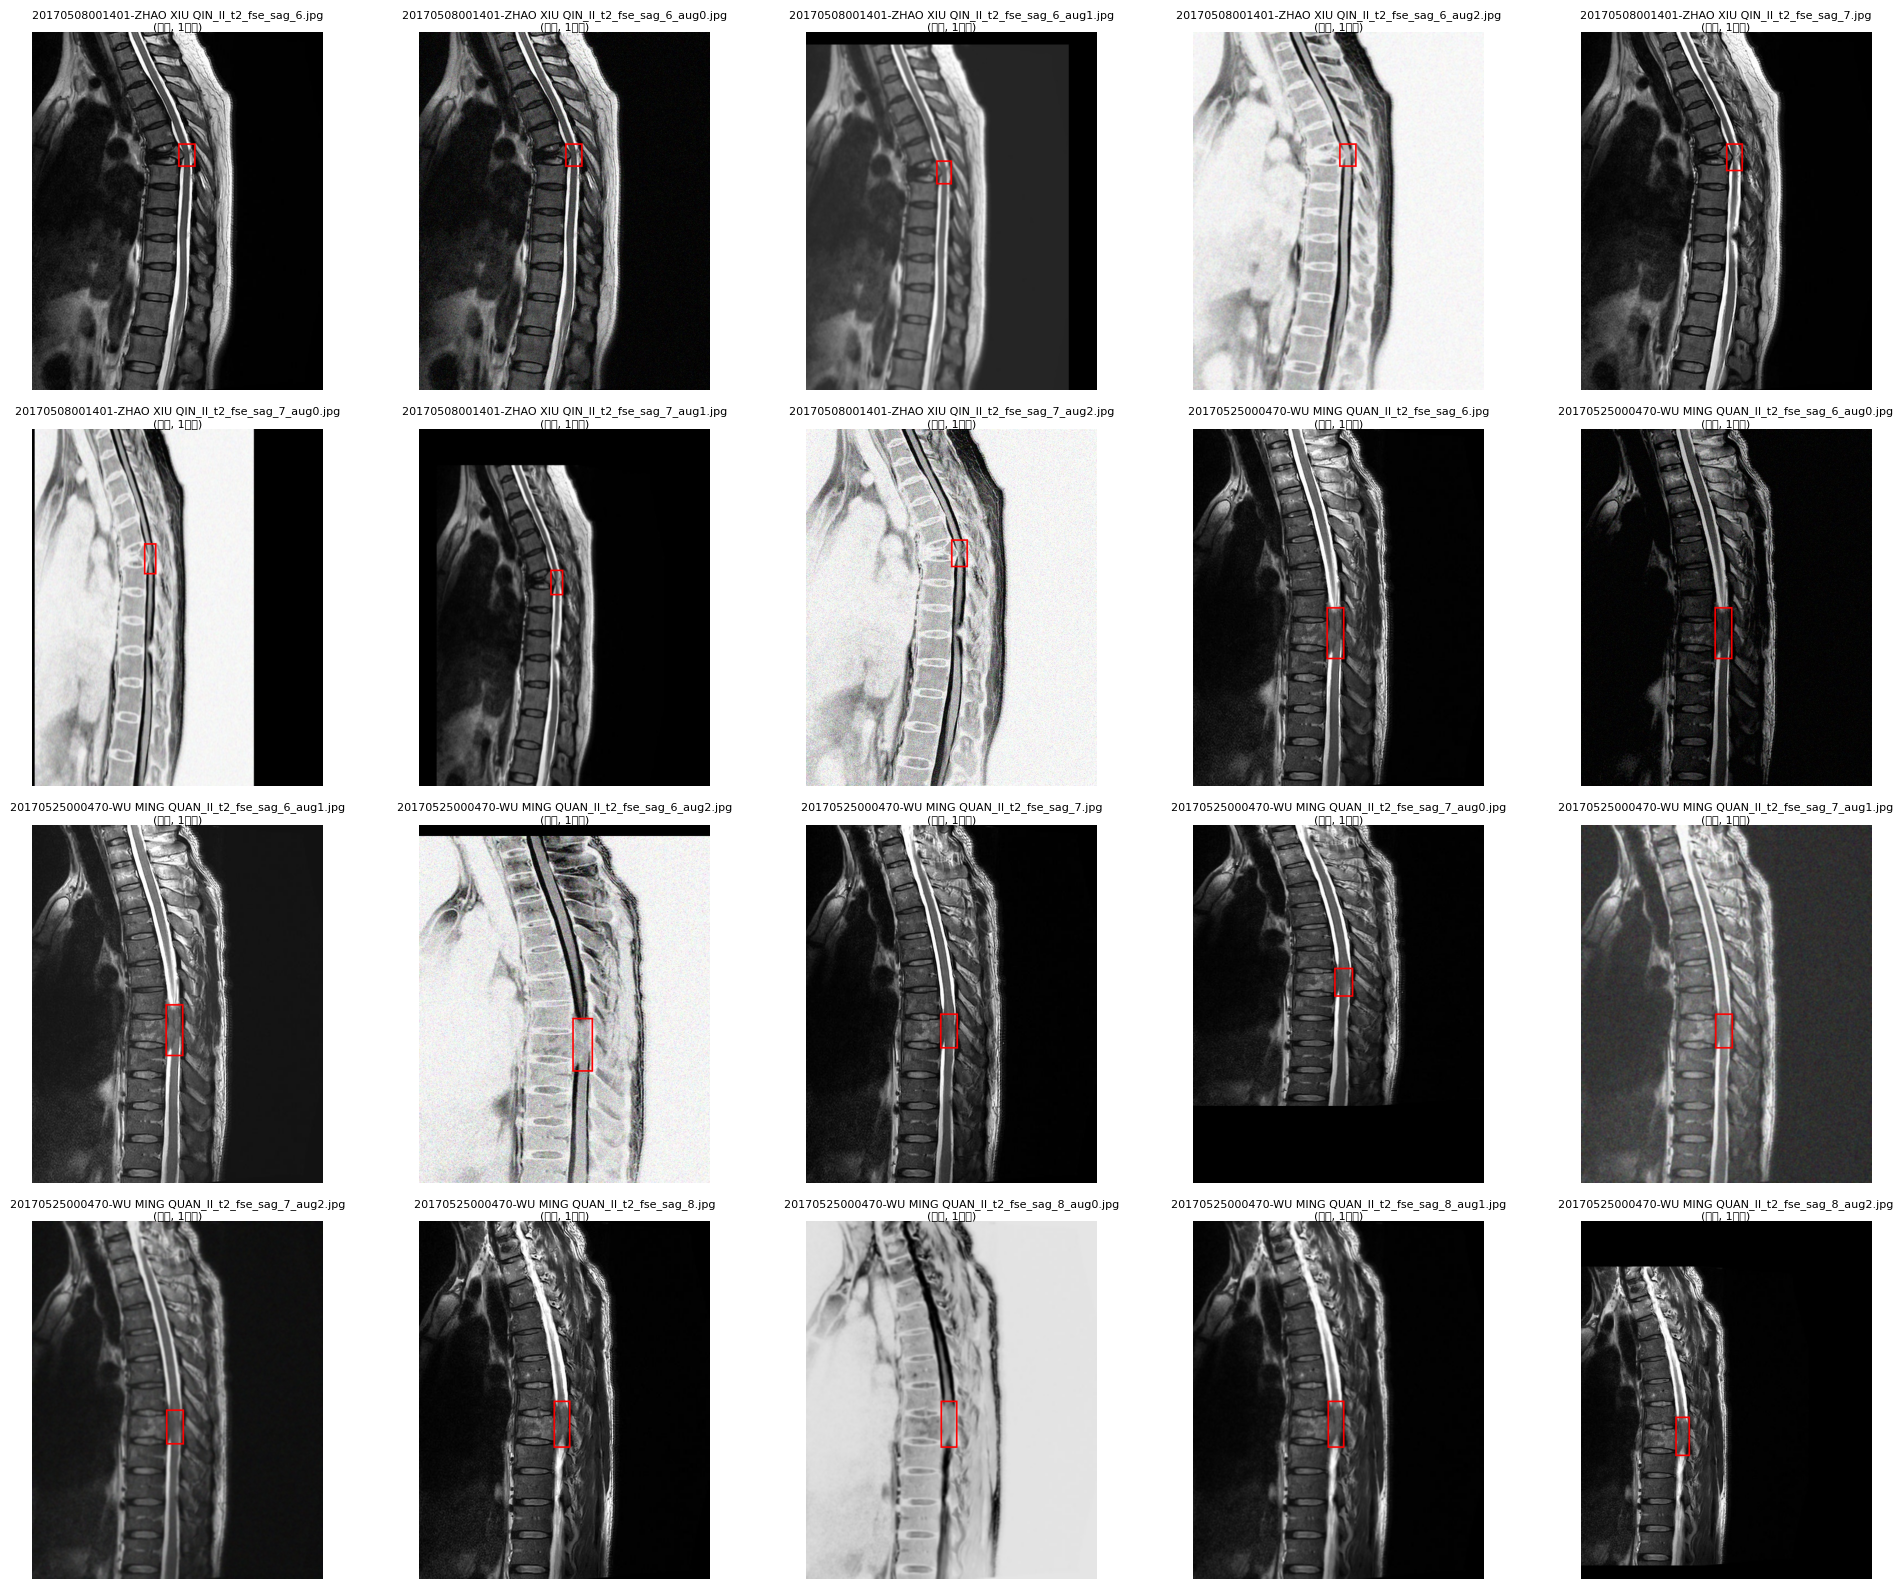

展示了 20 张图片 (索引 20 到 39)


In [49]:
# 调用函数展示下一批图片
plot_next_batch()

In [34]:
print(len(train_t2_jpg_label1_aug))
print(len(train_t2_json_label1_aug))
print(train_t2_jpg_label1_aug[0:5])
print(train_t2_json_label1_aug[0:5])

1684
1684
['D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_jpg_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10.jpg', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_jpg_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug0.jpg', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_jpg_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug1.jpg', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_jpg_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug2.jpg', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_jpg_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_9.jpg']
['D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_json_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10.json', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_json_label1_aug\\20170324000769-CHENG QIAN QIAN_t2_tse_sag_384_10_aug0.json', 'D:\\MED\\SpM\\SpMjpg-20240920-sagcopy-mini\\train_t2_json_label1_aug\\20170324000769-CHEN

# sag YOLO

In [ ]:
# model training
import torch
from torch.utils.data import Dataset, DataLoader
import pydicom
import numpy as np
from PIL import Image
import json
import os
from ultralytics import YOLO
import shutil
from tqdm import tqdm
import glob

# YOLO style data conversion
def convert_to_yolo_format(dcm_paths, json_paths, output_dir):
    images_dir = os.path.join(output_dir, 'images')
    labels_dir = os.path.join(output_dir, 'labels')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    
    for i, (dcm_path, json_path) in enumerate(zip(dcm_paths, json_paths)):
        try:
            img = Image.open(dcm_path)
            img_filename = os.path.basename(dcm_path)
            new_img_path = os.path.join(images_dir, img_filename)
            img.save(new_img_path)
            
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            width, height = img.size
            
            label_filename = os.path.splitext(img_filename)[0] + '.txt'
            label_path = os.path.join(labels_dir, label_filename)
            
            with open(label_path, 'w') as f:
                for shape in data.get('shapes', []):
                    if shape['shape_type'] == 'rectangle':
                        points = shape.get('points', [])
                        if len(points) == 2:
                            x_min, y_min = points[0]
                            x_max, y_max = points[1]
                            
                            x_center = (x_min + x_max) / 2 / width
                            y_center = (y_min + y_max) / 2 / height
                            bbox_width = (x_max - x_min) / width
                            bbox_height = (y_max - y_min) / height
                            
                            class_id = 0
                            
                            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")
            
        except Exception as e:
            print(f"Error processing {dcm_path}: {e}")
            continue
    
    return images_dir, labels_dir

def create_dataset_yaml(train_dir, val_dir, test_dir, output_path):
    """
    创建YOLO数据集配置文件
    """
    yaml_content = f"""
path: {os.path.dirname(output_path)}
train: {train_dir}
val: {val_dir}
test: {test_dir}

nc: 1  # number of classes
names: ['spinal_compression']  # class names
"""
    
    with open(output_path, 'w') as f:
        f.write(yaml_content.strip())
    
    return output_path

def train_yolo_model_with_custom_save(model, dataset_yaml, save_dir, epochs=100, device='cuda'):
    """
    训练YOLO模型并直接保存到指定目录
    """
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"训练结果将直接保存到: {save_dir}")
    
    # 训练模型 - 直接指定项目目录
    results = model.train(
        data=dataset_yaml,
        epochs=epochs,
        imgsz=640,           # 图像大小
        batch=32,            # 批次大小
        lr0=0.01,            # 初始学习率
        lrf=0.01,            # 最终学习率
        momentum=0.937,      # 动量
        weight_decay=0.0005, # 权重衰减
        warmup_epochs=3.0,   # 热身epochs
        warmup_momentum=0.8, # 热身动量
        warmup_bias_lr=0.1,  # 热身偏置学习率
        box=7.5,             # 框损失权重
        cls=0.5,             # 分类损失权重
        dfl=1.5,             # DFL损失权重
        save=True,           # 保存检查点
        save_period=1,       # 每个epoch都保存
        device=device,       # 使用GPU
        workers=8,           # 数据加载工作进程数
        project=save_dir,    # 直接指定项目目录
        name='yolov8_exp',   # 实验名称
        exist_ok=True,       # 覆盖现有实验
        patience=30,         # 早停耐心值
        val=True,            # 在训练期间验证
        amp=True,            # 自动混合精度
        plots=True,          # 绘制训练曲线
    )
    
    return model, results

def copy_best_model_to_custom_dir(model, save_dir):
    try:
        # 现在训练结果直接保存在目标目录中
        yolo_save_dir = os.path.join(save_dir, "yolov8_exp", "weights")
        if os.path.exists(yolo_save_dir):
            best_model_path = os.path.join(yolo_save_dir, "best.pt")
            last_model_path = os.path.join(yolo_save_dir, "last.pt")
            
            if os.path.exists(best_model_path):
                # 复制最佳模型到根目录方便访问
                custom_best_path = os.path.join(save_dir, "best_model.pt")
                shutil.copy2(best_model_path, custom_best_path)
                print(f"✓ 最佳模型已复制到: {custom_best_path}")
            
            if os.path.exists(last_model_path):
                # 复制最后模型到根目录方便访问
                custom_last_path = os.path.join(save_dir, "last_model.pt")
                shutil.copy2(last_model_path, custom_last_path)
                print(f"✓ 最后模型已复制到: {custom_last_path}")
        
        # 也保存当前模型状态
        current_model_path = os.path.join(save_dir, "final_trained_model.pt")
        torch.save(model.model.state_dict(), current_model_path)
        print(f"✓ 当前模型状态已保存到: {current_model_path}")
        
    except Exception as e:
        print(f"复制模型失败: {e}")

def save_all_checkpoints_to_custom_dir(save_dir):
    try:
        checkpoint_dir = os.path.join(save_dir, "yolov8_exp")
        if os.path.exists(checkpoint_dir):
            print(f"✓ 训练结果已直接保存在: {checkpoint_dir}")
            
            display_saved_contents(checkpoint_dir)
        else:
            print("❌ 训练结果目录不存在")
            
    except Exception as e:
        print(f"检查训练结果失败: {e}")

def display_saved_contents(directory_path):
    """
    显示保存的内容
    """
    print(f"\n📁 训练结果内容:")
    try:
        for root, dirs, files in os.walk(directory_path):
            level = root.replace(directory_path, '').count(os.sep)
            indent = '  ' * level
            
            dir_name = os.path.basename(root) if root != directory_path else os.path.basename(directory_path)
            print(f"{indent}📁 {dir_name}/")
            
            subindent = '  ' * (level + 1)
            for file in files[:10]:  
                file_path = os.path.join(root, file)
                size = os.path.getsize(file_path) / 1024  # KB
                print(f"{subindent}📄 {file} ({size:.1f} KB)")
                
    except Exception as e:
        print(f"  无法读取目录内容: {e}")

def load_best_model_from_custom_dir(save_dir, fallback_model=None):
    """
    从自定义目录加载最佳模型
    """
    best_model_path = os.path.join(save_dir, "best_model.pt")
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        print(f"✓ 从自定义目录加载最佳模型: {best_model_path}")
        return model
    
    yolo_best_path = os.path.join(save_dir, "yolov8_exp", "weights", "best.pt")
    if os.path.exists(yolo_best_path):
        model = YOLO(yolo_best_path)
        print(f"✓ 从训练目录加载最佳模型: {yolo_best_path}")
        return model
    
    print("✗ 未找到最佳模型，使用备用模型")
    return fallback_model

print("正在转换数据集为YOLO格式...")

temp_dir = "yolo_spinal_dataset"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

train_images_dir, train_labels_dir = convert_to_yolo_format(
    train_t2_dcm_positive_aug, train_t2_json_positive_aug, 
    os.path.join(temp_dir, 'train')
)

val_images_dir, val_labels_dir = convert_to_yolo_format(
    valid_t2_dcm_positive, valid_t2_json_positive,
    os.path.join(temp_dir, 'val')
)

test_images_dir, test_labels_dir = convert_to_yolo_format(
    test_t2_dcm, test_t2_json,
    os.path.join(temp_dir, 'test')
)

dataset_yaml = create_dataset_yaml(
    'train/images', 'val/images', 'test/images',
    os.path.join(temp_dir, 'spinal_dataset.yaml')
)

print(f"数据集转换完成！配置文件位置: {dataset_yaml}")

print("初始化YOLO模型...")
model = YOLO('yolov8s.pt') 

model.model.nc = 1  # 1个类别: 脊髓压迫
print(f"模型类别数设置为: {model.model.nc}")

custom_save_dir = r"D:\MED\SpM\SpMdcm-20240920-sagcopy-mini"

print("开始训练YOLO模型...")
trained_model, results = train_yolo_model_with_custom_save(model, dataset_yaml, custom_save_dir, epochs=100, device='cuda')

print("训练完成！")

print("复制最佳模型到根目录...")
copy_best_model_to_custom_dir(trained_model, custom_save_dir)

print("显示训练结果...")
save_all_checkpoints_to_custom_dir(custom_save_dir)

def validate_yolo_model(model, dataset_yaml):
    """
    验证YOLO模型
    """
    print("开始验证模型...")
    metrics = model.val(data=dataset_yaml)
    return metrics

val_metrics = validate_yolo_model(trained_model, dataset_yaml)
print(f"验证结果: {val_metrics}")

best_model = load_best_model_from_custom_dir(custom_save_dir, trained_model)
print("最佳模型加载完成！")

def test_yolo_model(model, test_images_dir):
    """
    测试YOLO模型
    """
    print("开始测试模型...")
    
    test_images = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) 
                  if f.lower().endswith(('.dcm', '.jpeg', '.png'))]
    
    test_images = test_images[:5]
    
    results = model(test_images)
    
    for i, result in enumerate(results):
        print(f"图片 {i+1}:")
        print(f"  检测到 {len(result.boxes)} 个目标")
        if len(result.boxes) > 0:
            print(f"  置信度: {result.boxes.conf.cpu().numpy()}")
            print(f"  边界框: {result.boxes.xyxy.cpu().numpy()}")
    
    return results

test_results = test_yolo_model(best_model, test_images_dir)

def show_saved_models(save_dir):
    """
    显示已保存的模型文件
    """
    print(f"\n保存在 {save_dir} 中的模型文件:")
    if os.path.exists(save_dir):
        # 显示所有.pt文件
        pt_files = []
        for root, dirs, files in os.walk(save_dir):
            for file in files:
                if file.endswith('.pt'):
                    pt_files.append(os.path.join(root, file))
        
        for pt_file in pt_files:
            file_size = os.path.getsize(pt_file) / (1024 * 1024)  # MB
            relative_path = os.path.relpath(pt_file, save_dir)
            print(f"  📁 {relative_path} ({file_size:.1f} MB)")
        
        print(f"  总计: {len(pt_files)} 个模型文件")
        
        # 显示目录结构
        print(f"\n📂 目录结构:")
        display_directory_structure(save_dir)
        
    else:
        print("  目录不存在")

def display_directory_structure(directory, indent=0):
    """
    显示目录结构
    """
    try:
        items = os.listdir(directory)
        for item in items[:10]:  
            item_path = os.path.join(directory, item)
            prefix = "  " * indent
            
            if os.path.isdir(item_path):
                print(f"{prefix}📁 {item}/")
                if indent < 2:  
                    display_directory_structure(item_path, indent + 1)
            else:
                if item.endswith('.pt') or item.endswith('.png') or item.endswith('.dcm'):
                    size = os.path.getsize(item_path) / 1024  # KB
                    print(f"{prefix}📄 {item} ({size:.1f} KB)")
    except Exception as e:
        print(f"{prefix}  无法读取: {e}")

show_saved_models(custom_save_dir)

print(f"\n训练完成！所有训练结果已直接保存到: {custom_save_dir}")

def predict_single_image(model, image_path):
    """
    对单张图片进行预测
    """
    results = model(image_path)
    
    for r in results:
        im_array = r.plot() 
        im = Image.fromarray(im_array[..., ::-1])  
        im.show()  
    
    return results

d:\anaconda\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


正在转换数据集为YOLO格式...
数据集转换完成！配置文件位置: yolo_spinal_dataset\spinal_dataset.yaml
初始化YOLO模型...
模型类别数设置为: 1
开始训练YOLO模型...
训练结果将直接保存到: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini
New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.208  Python-3.11.5 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_spinal_dataset\spinal_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_widt